#Possible features of data:

Temperature
Humidity
Hour
Day
Previous Consumption
Number of Occupants
Solar Generation
Industrial Load

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [53]:
# Read the file as 
energy = pd.read_csv(r"C:\Users\PC\Downloads\electricityConsumptionAndProduction.csv")
energy

,Date,Time,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,1/1/2019,12:00:00 AM,6352,6527,1395,79,1383,1896,1744,0,30
1,1/1/2019,1:00:00 AM,6116,5701,1393,96,1112,1429,1641,0,30
2,1/1/2019,2:00:00 AM,5873,5676,1393,142,1030,1465,1616,0,30
3,1/1/2019,3:00:00 AM,5682,5603,1397,191,972,1455,1558,0,30
4,1/1/2019,4:00:00 AM,5557,5454,1393,159,960,1454,1458,0,30
...,...,...,...,...,...,...,...,...,...,...,...
62805,3/14/2026,7:00:00 PM,7132,6937,1339,699,2560,1590,598,0,59
62806,3/14/2026,8:00:00 PM,7027,6827,1339,744,2538,1571,579,0,58
62807,3/14/2026,9:00:00 PM,6615,6612,1341,778,2291,1569,578,0,60
62808,3/14/2026,10:00:00 PM,6063,6421,1335,701,2146,1556,586,0,61


In [55]:
energy["Date"] = pd.to_datetime(energy["Date"])

In [56]:
energy_2025 = energy[energy["Date"] >= "2025-01-01"]

In [57]:
energy_2025

,Date,Time,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
52468,2025-01-01,12:00:00 AM,5771,5289,1384,680,852,1621,723,0,37
52469,2025-01-01,1:00:00 AM,5610,5325,1389,691,878,1624,693,0,37
52470,2025-01-01,2:00:00 AM,5444,5346,1386,724,872,1624,698,0,38
52471,2025-01-01,3:00:00 AM,5249,5446,1387,829,864,1616,700,0,38
52472,2025-01-01,4:00:00 AM,5143,5427,1386,944,848,1508,704,0,37
...,...,...,...,...,...,...,...,...,...,...,...
62805,2026-03-14,7:00:00 PM,7132,6937,1339,699,2560,1590,598,0,59
62806,2026-03-14,8:00:00 PM,7027,6827,1339,744,2538,1571,579,0,58
62807,2026-03-14,9:00:00 PM,6615,6612,1341,778,2291,1569,578,0,60
62808,2026-03-14,10:00:00 PM,6063,6421,1335,701,2146,1556,586,0,61


In [59]:
energy_2025.head()

,Date,Time,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
52468,2025-01-01,12:00:00 AM,5771,5289,1384,680,852,1621,723,0,37
52469,2025-01-01,1:00:00 AM,5610,5325,1389,691,878,1624,693,0,37
52470,2025-01-01,2:00:00 AM,5444,5346,1386,724,872,1624,698,0,38
52471,2025-01-01,3:00:00 AM,5249,5446,1387,829,864,1616,700,0,38
52472,2025-01-01,4:00:00 AM,5143,5427,1386,944,848,1508,704,0,37


In [60]:
# Filter Solar-01
print("Rows for Solar:", len(energy_2025[energy_2025["Solar"] == "Solar-01"]))

Rows for Solar: 0


In [61]:
energy_2025 = energy_2025[["Date","Consumption", "Production", "Oil and Gas", "Solar", "Nuclear", "Hydroelectric", "Wind", "Coal", "Biomass"]]
energy_2025

,Date,Consumption,Production,Oil and Gas,Solar,Nuclear,Hydroelectric,Wind,Coal,Biomass
52468,2025-01-01,5771,5289,1621,0,1384,852,680,723,37
52469,2025-01-01,5610,5325,1624,0,1389,878,691,693,37
52470,2025-01-01,5444,5346,1624,0,1386,872,724,698,38
52471,2025-01-01,5249,5446,1616,0,1387,864,829,700,38
52472,2025-01-01,5143,5427,1508,0,1386,848,944,704,37
...,...,...,...,...,...,...,...,...,...,...
62805,2026-03-14,7132,6937,1590,0,1339,2560,699,598,59
62806,2026-03-14,7027,6827,1571,0,1339,2538,744,579,58
62807,2026-03-14,6615,6612,1569,0,1341,2291,778,578,60
62808,2026-03-14,6063,6421,1556,0,1335,2146,701,586,61


In [62]:
energy_2025.corr(numeric_only=True)["Consumption"]

Consumption      1.000000
Production       0.681974
Oil and Gas      0.556046
Solar           -0.257548
Nuclear          0.229595
Hydroelectric    0.570707
Wind             0.139935
Coal             0.504258
Biomass          0.477551
Name: Consumption, dtype: float64

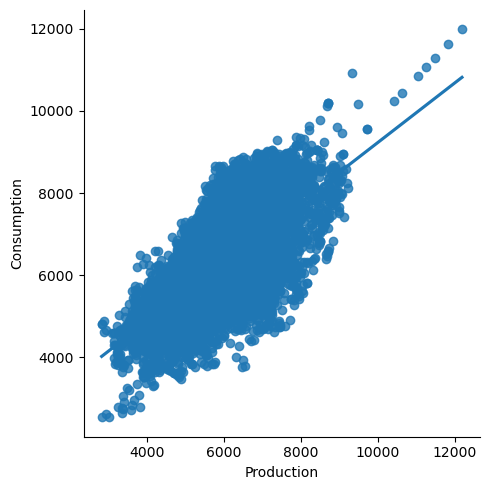

In [63]:
sns.lmplot(x="Production",y="Consumption", data=energy_2025, fit_reg=True, ci= None)

<Axes: ylabel='Frequency'>

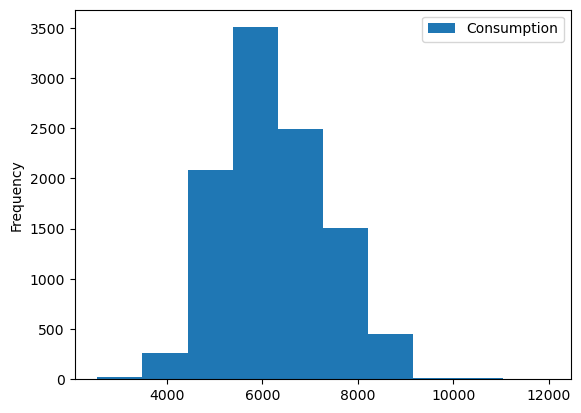

In [64]:
energy_2025.plot.hist(y="Consumption")

In [65]:
energy_2025[energy_2025.isnull().any(axis=1)]

,Date,Consumption,Production,Oil and Gas,Solar,Nuclear,Hydroelectric,Wind,Coal,Biomass


In [66]:
train = energy_2025[energy_2025["Date"] < "2026-01-01"].copy()
test = energy_2025[energy_2025["Date"] >= "2026-01-01"].copy()

In [67]:
train.shape

(8590, 10)

In [68]:
test.shape

(1752, 10)

In [69]:
reg = LinearRegression()

In [70]:
predictors = ["Production", "Oil and Gas"]
target = "Comsumption"

In [72]:
reg.fit(train[predictors], train["Consumption"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
LinearRegression()

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
predictions = reg.predict(test[predictors])

In [75]:
predictions

array([6611.58444444, 6206.05017203, 6139.36425096, ..., 6829.3550286 ,
       6714.98725805, 6599.29913511], shape=(1752,))

In [76]:
test["predictions"] = predictions

In [77]:
test

,Date,Consumption,Production,Oil and Gas,Solar,Nuclear,Hydroelectric,Wind,Coal,Biomass,predictions
61058,2026-01-01,5904,5956,1877,0,1336,1303,632,755,50,6611.584444
61059,2026-01-01,5655,5240,1875,0,1333,955,401,596,47,6206.050172
61060,2026-01-01,5475,5129,1867,0,1338,942,362,571,48,6139.364251
61061,2026-01-01,5335,4987,1857,0,1339,887,271,584,49,6054.170592
61062,2026-01-01,5278,4949,1875,0,1335,967,138,585,48,6041.634520
...,...,...,...,...,...,...,...,...,...,...,...
62805,2026-03-14,7132,6937,1590,0,1339,2560,699,598,59,7023.403772
62806,2026-03-14,7027,6827,1571,0,1339,2538,744,579,58,6951.823178
62807,2026-03-14,6615,6612,1569,0,1341,2291,778,578,60,6829.355029
62808,2026-03-14,6063,6421,1556,0,1335,2146,701,586,61,6714.987258


In [78]:
test["predictions"] = test["predictions"].round()

In [79]:
test

,Date,Consumption,Production,Oil and Gas,Solar,Nuclear,Hydroelectric,Wind,Coal,Biomass,predictions
61058,2026-01-01,5904,5956,1877,0,1336,1303,632,755,50,6612.0
61059,2026-01-01,5655,5240,1875,0,1333,955,401,596,47,6206.0
61060,2026-01-01,5475,5129,1867,0,1338,942,362,571,48,6139.0
61061,2026-01-01,5335,4987,1857,0,1339,887,271,584,49,6054.0
61062,2026-01-01,5278,4949,1875,0,1335,967,138,585,48,6042.0
...,...,...,...,...,...,...,...,...,...,...,...
62805,2026-03-14,7132,6937,1590,0,1339,2560,699,598,59,7023.0
62806,2026-03-14,7027,6827,1571,0,1339,2538,744,579,58,6952.0
62807,2026-03-14,6615,6612,1569,0,1341,2291,778,578,60,6829.0
62808,2026-03-14,6063,6421,1556,0,1335,2146,701,586,61,6715.0


In [80]:
error = mean_absolute_error(test["Consumption"], test["predictions"])

In [81]:
error

692.4663242009133

In [82]:
energy_2025.describe()["Consumption"]

count    10342.000000
mean      6243.274028
min       2542.000000
25%       5436.250000
50%       6114.000000
75%       7003.000000
max      11986.000000
std       1094.776184
Name: Consumption, dtype: float64

In [83]:
errors = (test["Consumption"] - test["predictions"]).abs()

In [84]:
errors

61058    708.0
61059    551.0
61060    664.0
61061    719.0
61062    764.0
         ...  
62805    109.0
62806     75.0
62807    214.0
62808    652.0
62809    887.0
Length: 1752, dtype: float64